In [74]:
# ============================================================
# BAGIAN 0: INSTALASI DAN IMPORT LIBRARY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# Pengaturan tampilan plot
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


In [75]:
# ============================================================
# BAGIAN 1: MEMUAT DATASET
# ============================================================

# Muat dataset dari file Excel
# Ganti nama file sesuai dengan nama file yang diupload
df = pd.read_excel('../OnlineRetail.xlsx')

# Tampilkan 5 data pertama untuk eksplorasi awal
print("\n📋 Lima data pertama:")
print(df.head())

# Tampilkan informasi struktur dataset
print("\n📊 Informasi struktur dataset:")
print(df.info())

# Tampilkan jumlah missing value per kolom
print("\n❓ Jumlah missing value per kolom:")
print(df.isnull().sum())

# Tampilkan statistik deskriptif
print("\n📈 Statistik deskriptif:")
print(df.describe())

print(f"\n✅ Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")


📋 Lima data pertama:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

📊 Informasi struktur dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null

In [76]:
# ============================================================
# BAGIAN 2: PREPROCESSING DATA
# ============================================================
# Salin dataframe agar data asli tidak berubah
df_clean = df.copy()

# 2.1 Konversi kolom InvoiceDate ke format datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
print(f"✅ Kolom InvoiceDate berhasil dikonversi ke datetime")

# 2.2 Hapus baris dengan missing value
before = len(df_clean)
df_clean = df_clean.dropna()
after = len(df_clean)
print(f"✅ Hapus missing value: {before - after} baris dihapus")

# 2.3 Hapus data tanpa CustomerID (CustomerID kosong atau 0)
before = len(df_clean)
df_clean = df_clean[df_clean['CustomerID'].notna()]
df_clean = df_clean[df_clean['CustomerID'] != 0]
after = len(df_clean)
print(f"✅ Hapus data tanpa CustomerID: {before - after} baris dihapus")

# 2.4 Hapus transaksi dengan Quantity <= 0
# (transaksi negatif biasanya adalah pengembalian/retur)
before = len(df_clean)
df_clean = df_clean[df_clean['Quantity'] > 0]
after = len(df_clean)
print(f"✅ Hapus Quantity <= 0: {before - after} baris dihapus")

# 2.5 Hapus transaksi dengan UnitPrice <= 0
before = len(df_clean)
df_clean = df_clean[df_clean['UnitPrice'] > 0]
after = len(df_clean)
print(f"✅ Hapus UnitPrice <= 0: {before - after} baris dihapus")

# 2.6 Hapus data duplikat
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"✅ Hapus duplikat: {before - after} baris dihapus")

# Konversi CustomerID ke integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

print(f"\n✅ Preprocessing selesai: {len(df_clean)} baris data bersih")
print(f"   (dari {len(df)} baris data awal)")


✅ Kolom InvoiceDate berhasil dikonversi ke datetime
✅ Hapus missing value: 135080 baris dihapus
✅ Hapus data tanpa CustomerID: 0 baris dihapus
✅ Hapus Quantity <= 0: 8905 baris dihapus
✅ Hapus UnitPrice <= 0: 40 baris dihapus
✅ Hapus duplikat: 5192 baris dihapus

✅ Preprocessing selesai: 392692 baris data bersih
   (dari 541909 baris data awal)


In [77]:
# ============================================================
# BAGIAN 3: FEATURE ENGINEERING - PEMBENTUKAN VARIABEL RFM
# ============================================================
# Tentukan tanggal referensi (tanggal maksimum dalam dataset + 1 hari)
tanggal_referensi = df_clean['InvoiceDate'].max() + pd.DateOffset(days=1)
print(f"📅 Tanggal referensi: {tanggal_referensi.date()}")

# PERBAIKAN: Hitung TotalSum dulu sebelum groupby
df_clean['TotalSum'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Hitung nilai RFM per CustomerID
rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (tanggal_referensi - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalSum',    'sum')
).reset_index()

# Tampilkan hasil RFM
print("\n📋 Lima data RFM pertama:")
print(rfm.head())

print("\n📊 Statistik RFM:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

print(f"\n✅ RFM berhasil dibentuk: {len(rfm)} pelanggan")

📅 Tanggal referensi: 2011-12-10

📋 Lima data RFM pertama:
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40

📊 Statistik RFM:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000

✅ RFM berhasil dibentuk: 4338 pelanggan


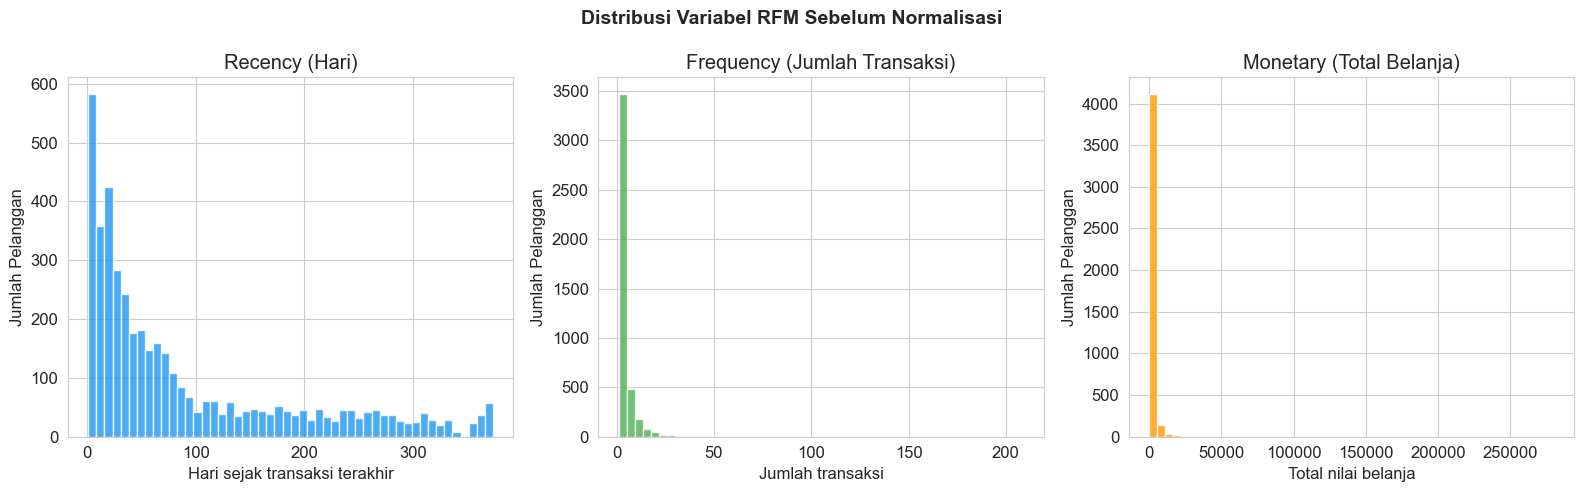

✅ Distribusi RFM berhasil divisualisasikan


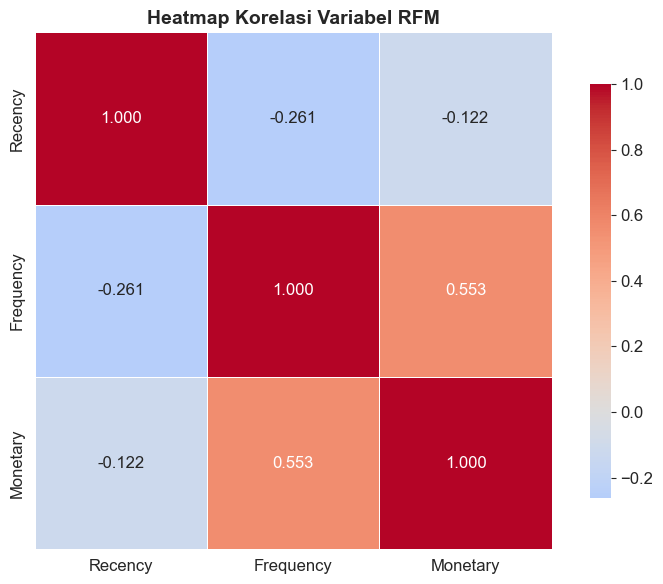

✅ Heatmap korelasi berhasil divisualisasikan


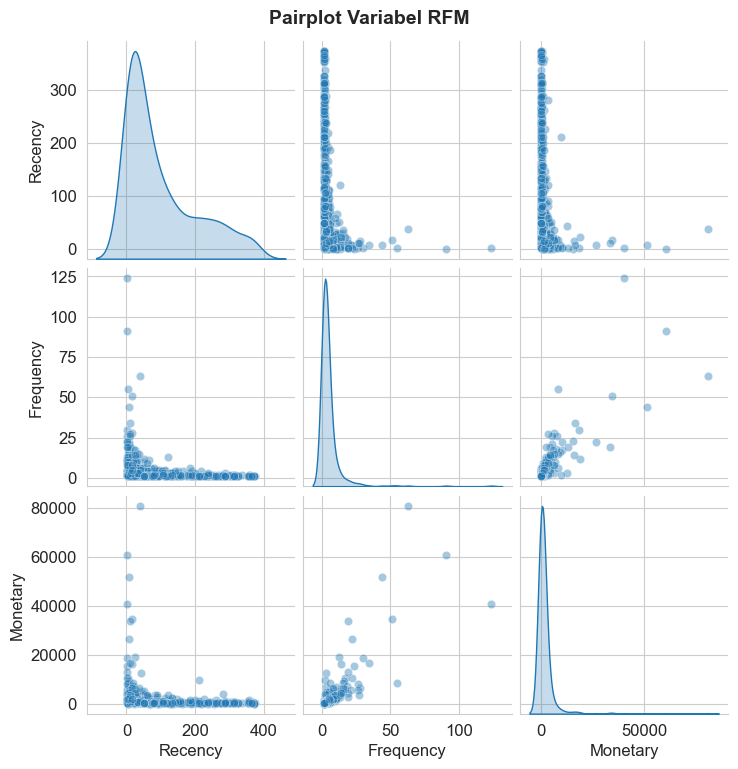

✅ Pairplot RFM berhasil divisualisasikan


In [78]:
# ============================================================
# BAGIAN 4: VISUALISASI DISTRIBUSI RFM
# ============================================================
# Histogram distribusi R, F, M
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribusi Variabel RFM Sebelum Normalisasi', fontsize=14, fontweight='bold')

axes[0].hist(rfm['Recency'],   bins=50, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0].set_title('Recency (Hari)')
axes[0].set_xlabel('Hari sejak transaksi terakhir')
axes[0].set_ylabel('Jumlah Pelanggan')

axes[1].hist(rfm['Frequency'], bins=50, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1].set_title('Frequency (Jumlah Transaksi)')
axes[1].set_xlabel('Jumlah transaksi')
axes[1].set_ylabel('Jumlah Pelanggan')

axes[2].hist(rfm['Monetary'],  bins=50, color='#FF9800', edgecolor='white', alpha=0.8)
axes[2].set_title('Monetary (Total Belanja)')
axes[2].set_xlabel('Total nilai belanja')
axes[2].set_ylabel('Jumlah Pelanggan')

plt.tight_layout()
plt.savefig('distribusi_rfm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Distribusi RFM berhasil divisualisasikan")

# Heatmap korelasi antar variabel RFM
plt.figure(figsize=(8, 6))
korelasi = rfm[['Recency', 'Frequency', 'Monetary']].corr()
sns.heatmap(korelasi, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Variabel RFM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi_rfm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap korelasi berhasil divisualisasikan")

# Pairplot distribusi RFM
rfm_sample = rfm[['Recency', 'Frequency', 'Monetary']].sample(
    min(500, len(rfm)), random_state=42
)
pairplot = sns.pairplot(rfm_sample, diag_kind='kde', plot_kws={'alpha': 0.4})
pairplot.fig.suptitle('Pairplot Variabel RFM', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pairplot_rfm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Pairplot RFM berhasil divisualisasikan")

In [79]:
# ============================================================
# BAGIAN 5: NORMALISASI DATA (LOG TRANSFORMATION + Z-SCORE)
# ============================================================
# Ambil fitur RFM untuk normalisasi
fitur_rfm = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# PERBAIKAN: 1. Lakukan Log Transformation
fitur_rfm_log = np.log1p(fitur_rfm) 

# PERBAIKAN: 2. Lakukan Z-Score hanya pada data yang sudah di-log
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(fitur_rfm_log)

# Ubah ke DataFrame untuk kemudahan
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'],
    index=rfm['CustomerID'] # Gunakan index CustomerID agar terhubung
)

print("📊 Statistik setelah normalisasi:")
print(rfm_scaled_df.describe().round(4))
print("\n✅ Normalisasi Z-score pada data Log berhasil dilakukan")

📊 Statistik setelah normalisasi:
       Recency_scaled  Frequency_scaled  Monetary_scaled
count       4338.0000         4338.0000        4338.0000
mean          -0.0000           -0.0000          -0.0000
std            1.0001            1.0001           1.0001
min           -2.3413           -0.9552          -3.9978
25%           -0.6614           -0.9552          -0.6836
50%            0.0899           -0.3616          -0.0651
75%            0.8448            0.6532           0.6572
max            1.5642            5.8585           4.7324

✅ Normalisasi Z-score pada data Log berhasil dilakukan



📊 Menentukan jumlah cluster optimal (Elbow Method + Silhouette Score)...


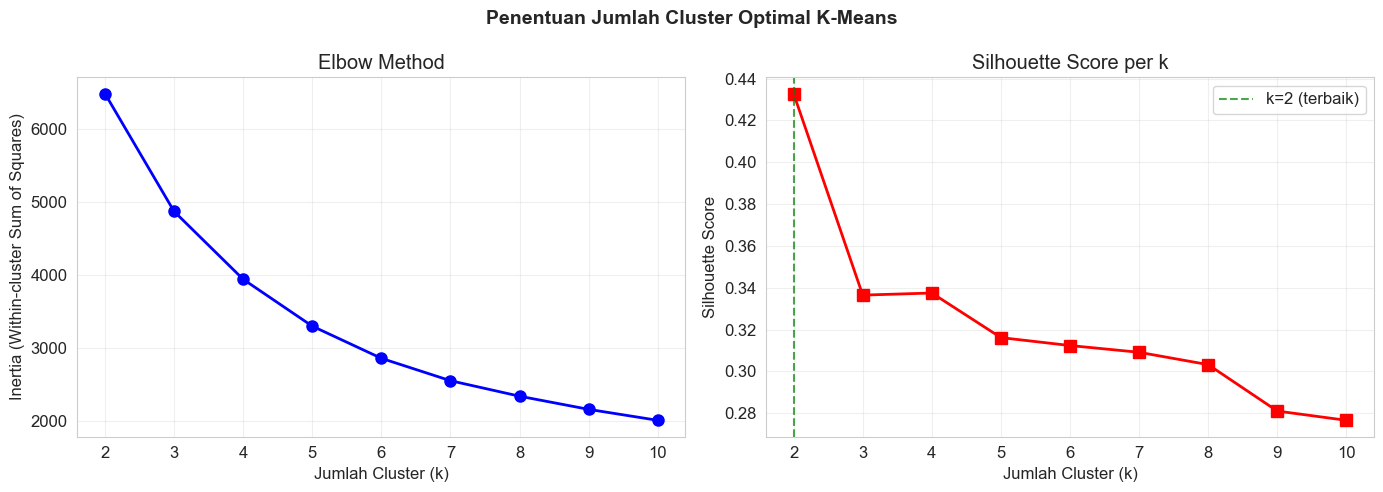


📋 Silhouette Score per jumlah cluster:
 k  Silhouette Score
 2          0.432827
 3          0.336517
 4          0.337517
 5          0.316200
 6          0.312409
 7          0.309186
 8          0.303275
 9          0.281085
10          0.276659

➡️  k optimal berdasarkan Silhouette Score tertinggi: k = 2

✅ K-Means selesai dengan k = 2
   Silhouette Score : 0.4328
   Davies-Bouldin Index: 0.8925

📊 Jumlah anggota per cluster K-Means:
Cluster_KMeans
0    2672
1    1666
Name: count, dtype: int64


In [80]:
# ============================================================
# BAGIAN 6: K-MEANS CLUSTERING
# ============================================================
# --- 6.1 Menentukan k optimal dengan Elbow Method ---
print("\n📊 Menentukan jumlah cluster optimal (Elbow Method + Silhouette Score)...")

inertia_list    = []
silhouette_list = []
k_range         = range(2, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(rfm_scaled)
    inertia_list.append(kmeans_temp.inertia_)
    sil_score = silhouette_score(rfm_scaled, kmeans_temp.labels_)
    silhouette_list.append(sil_score)

# Plot Elbow dan Silhouette berdampingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Penentuan Jumlah Cluster Optimal K-Means', fontsize=14, fontweight='bold')

# Elbow Method
axes[0].plot(k_range, inertia_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

# Silhouette Score
axes[1].plot(k_range, silhouette_list, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per k')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

# Tandai nilai terbaik
k_terbaik_sil = k_range[np.argmax(silhouette_list)]
axes[1].axvline(x=k_terbaik_sil, color='green', linestyle='--', alpha=0.7,
                label=f'k={k_terbaik_sil} (terbaik)')
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

# Tampilkan tabel Silhouette Score
print("\n📋 Silhouette Score per jumlah cluster:")
tabel_k = pd.DataFrame({'k': list(k_range), 'Silhouette Score': silhouette_list})
print(tabel_k.to_string(index=False))
print(f"\n➡️  k optimal berdasarkan Silhouette Score tertinggi: k = {k_terbaik_sil}")

# --- 6.2 Jalankan K-Means dengan k optimal ---
k_optimal = k_terbaik_sil  # Bisa diubah manual sesuai analisis Elbow

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm['Cluster_KMeans'] = kmeans.fit_predict(rfm_scaled)

# Evaluasi K-Means
sil_kmeans = silhouette_score(rfm_scaled, rfm['Cluster_KMeans'])
dbi_kmeans = davies_bouldin_score(rfm_scaled, rfm['Cluster_KMeans'])

print(f"\n✅ K-Means selesai dengan k = {k_optimal}")
print(f"   Silhouette Score : {sil_kmeans:.4f}")
print(f"   Davies-Bouldin Index: {dbi_kmeans:.4f}")

# Tampilkan jumlah anggota per cluster
print("\n📊 Jumlah anggota per cluster K-Means:")
print(rfm['Cluster_KMeans'].value_counts().sort_index())



📊 Membuat dendrogram untuk menentukan jumlah cluster...
   (Menggunakan 500 sampel acak untuk dendrogram)


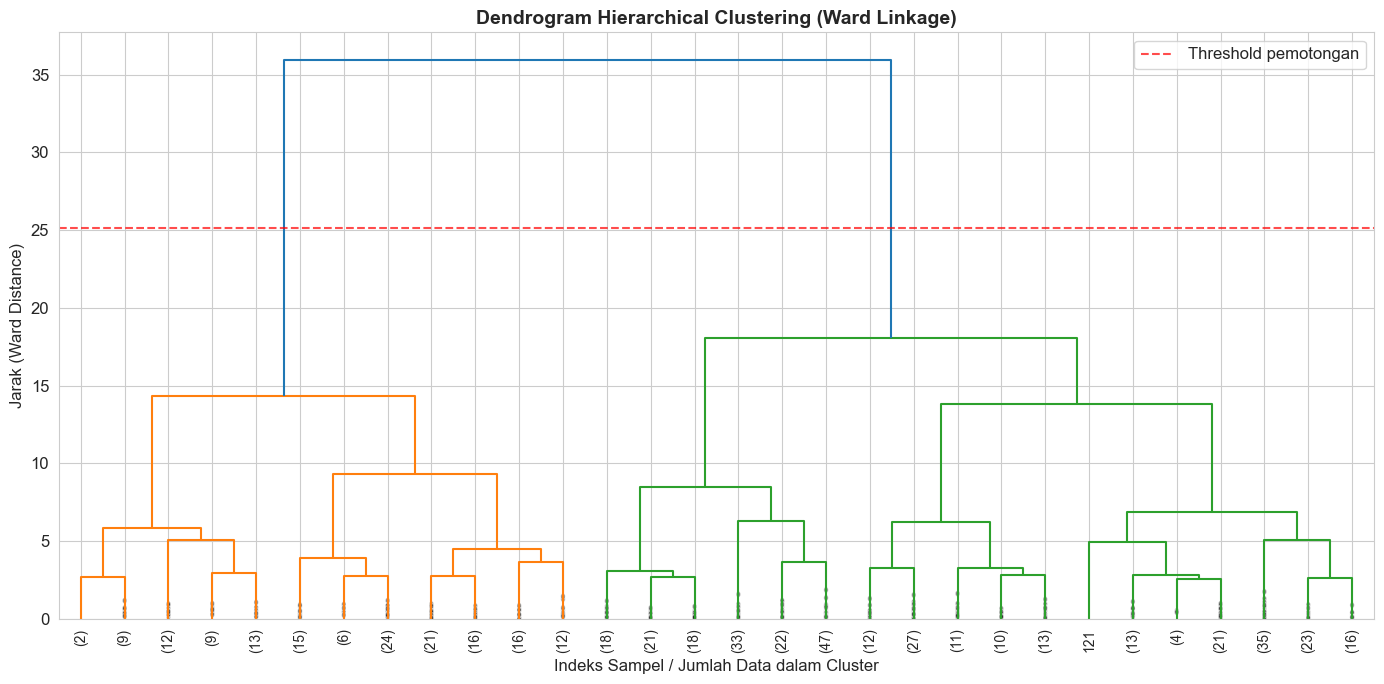

✅ Dendrogram berhasil ditampilkan

➡️  Jumlah cluster yang digunakan: 2

✅ Hierarchical Clustering selesai dengan k = 2
   Silhouette Score    : 0.4040
   Davies-Bouldin Index: 0.9405

📊 Jumlah anggota per cluster Hierarchical:
Cluster_Hierarchical
0    3233
1    1105
Name: count, dtype: int64


In [81]:
# ============================================================
# BAGIAN 7: HIERARCHICAL CLUSTERING
# ============================================================
# --- 7.1 Tampilkan Dendrogram ---
print("\n📊 Membuat dendrogram untuk menentukan jumlah cluster...")

# Gunakan sample jika data terlalu besar (dendrogram lambat untuk data besar)
max_sample = 500
if len(rfm_scaled) > max_sample:
    idx_sample = np.random.choice(len(rfm_scaled), max_sample, replace=False)
    rfm_sample_hc = rfm_scaled[idx_sample]
    print(f"   (Menggunakan {max_sample} sampel acak untuk dendrogram)")
else:
    rfm_sample_hc = rfm_scaled

# Hitung linkage matrix
linkage_matrix = linkage(rfm_sample_hc, method='ward')

# Plot dendrogram
plt.figure(figsize=(14, 7))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=0.7 * max(linkage_matrix[:, 2])
)
plt.title('Dendrogram Hierarchical Clustering (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Indeks Sampel / Jumlah Data dalam Cluster')
plt.ylabel('Jarak (Ward Distance)')
plt.axhline(y=0.7 * max(linkage_matrix[:, 2]),
            color='red', linestyle='--', alpha=0.7, label='Threshold pemotongan')
plt.legend()
plt.tight_layout()
plt.savefig('hierarchical_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dendrogram berhasil ditampilkan")

# --- 7.2 Tentukan jumlah cluster Hierarchical ---
# Tentukan jumlah cluster berdasarkan analisis dendrogram
# Defaultnya sama dengan k_optimal K-Means, bisa diubah
k_hierarchical = k_optimal
print(f"\n➡️  Jumlah cluster yang digunakan: {k_hierarchical}")

# Jalankan Hierarchical Clustering pada seluruh data
hierarchical = AgglomerativeClustering(n_clusters=k_hierarchical, linkage='ward')
rfm['Cluster_Hierarchical'] = hierarchical.fit_predict(rfm_scaled)

# Evaluasi Hierarchical Clustering
sil_hc = silhouette_score(rfm_scaled, rfm['Cluster_Hierarchical'])
dbi_hc = davies_bouldin_score(rfm_scaled, rfm['Cluster_Hierarchical'])

print(f"\n✅ Hierarchical Clustering selesai dengan k = {k_hierarchical}")
print(f"   Silhouette Score    : {sil_hc:.4f}")
print(f"   Davies-Bouldin Index: {dbi_hc:.4f}")

# Tampilkan jumlah anggota per cluster
print("\n📊 Jumlah anggota per cluster Hierarchical:")
print(rfm['Cluster_Hierarchical'].value_counts().sort_index())


📊 Menentukan nilai epsilon menggunakan k-distance graph...
   Nilai minPts = 2 × 3 dimensi = 6


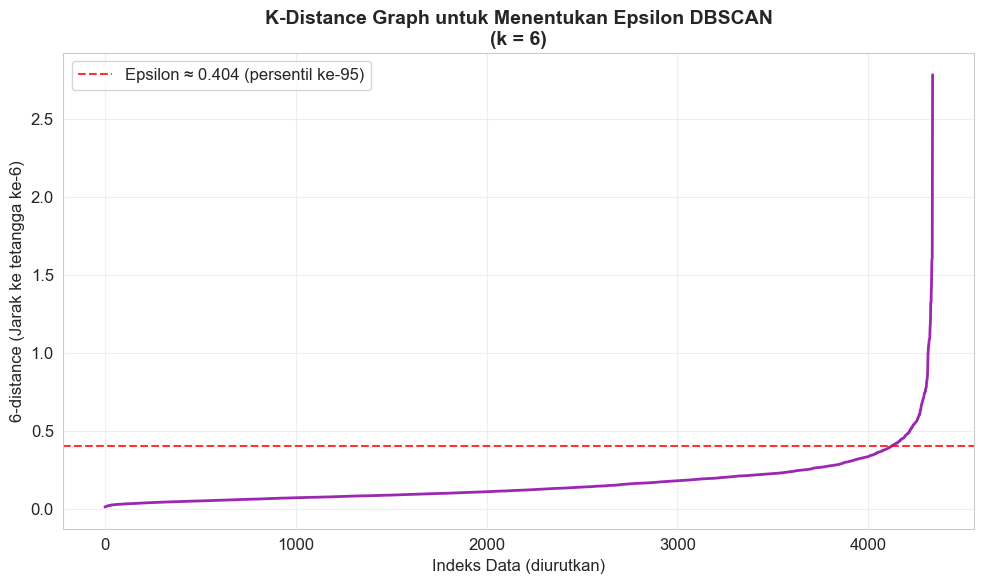


➡️  Nilai epsilon yang digunakan: 0.4044
   (Nilai ini dapat disesuaikan secara manual berdasarkan analisis grafik)

✅ DBSCAN selesai
   Jumlah cluster terbentuk : 3
   Jumlah noise (label = -1): 116 pelanggan
   Persentase noise          : 2.67%

   Silhouette Score    : 0.1708 (dihitung tanpa noise)
   Davies-Bouldin Index: 1.6985 (dihitung tanpa noise)

📊 Distribusi cluster DBSCAN (label -1 = noise):
Cluster_DBSCAN
-1     116
 0    1921
 1    1474
 2     827
Name: count, dtype: int64


In [82]:
# ============================================================
# BAGIAN 8: DBSCAN CLUSTERING
# ============================================================
# --- 8.1 Tentukan epsilon menggunakan k-distance graph ---
print("\n📊 Menentukan nilai epsilon menggunakan k-distance graph...")

# minPts = 2 * jumlah dimensi (aturan umum)
n_fitur = rfm_scaled.shape[1]
min_pts = 2 * n_fitur
print(f"   Nilai minPts = 2 × {n_fitur} dimensi = {min_pts}")

# Hitung k-distance
nbrs = NearestNeighbors(n_neighbors=min_pts).fit(rfm_scaled)
distances, _ = nbrs.kneighbors(rfm_scaled)
distances = np.sort(distances[:, -1], axis=0)

# Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances, linewidth=2, color='#9C27B0')
plt.xlabel('Indeks Data (diurutkan)')
plt.ylabel(f'{min_pts}-distance (Jarak ke tetangga ke-{min_pts})')
plt.title(f'K-Distance Graph untuk Menentukan Epsilon DBSCAN\n(k = {min_pts})',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Tentukan epsilon dari titik "elbow" pada k-distance graph
# Pendekatan otomatis: ambil persentil ke-95
epsilon = np.percentile(distances, 95)
plt.axhline(y=epsilon, color='red', linestyle='--', alpha=0.8,
            label=f'Epsilon ≈ {epsilon:.3f} (persentil ke-95)')
plt.legend()
plt.tight_layout()
plt.savefig('dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n➡️  Nilai epsilon yang digunakan: {epsilon:.4f}")
print(f"   (Nilai ini dapat disesuaikan secara manual berdasarkan analisis grafik)")

# --- 8.2 Jalankan DBSCAN ---
dbscan = DBSCAN(eps=epsilon, min_samples=min_pts)
rfm['Cluster_DBSCAN'] = dbscan.fit_predict(rfm_scaled)

# Hitung jumlah cluster dan noise
n_cluster_dbscan = len(set(rfm['Cluster_DBSCAN'])) - (1 if -1 in rfm['Cluster_DBSCAN'].values else 0)
n_noise_dbscan   = (rfm['Cluster_DBSCAN'] == -1).sum()

print(f"\n✅ DBSCAN selesai")
print(f"   Jumlah cluster terbentuk : {n_cluster_dbscan}")
print(f"   Jumlah noise (label = -1): {n_noise_dbscan} pelanggan")
print(f"   Persentase noise          : {n_noise_dbscan/len(rfm)*100:.2f}%")

# Evaluasi DBSCAN (hanya untuk data non-noise)
mask_non_noise = rfm['Cluster_DBSCAN'] != -1
if mask_non_noise.sum() > 1 and n_cluster_dbscan > 1:
    mask_non_noise_arr = mask_non_noise.values
    sil_dbscan = silhouette_score(rfm_scaled[mask_non_noise_arr], rfm['Cluster_DBSCAN'][mask_non_noise_arr])
    dbi_dbscan = davies_bouldin_score(rfm_scaled[mask_non_noise_arr], rfm['Cluster_DBSCAN'][mask_non_noise_arr])
    print(f"\n   Silhouette Score    : {sil_dbscan:.4f} (dihitung tanpa noise)")
    print(f"   Davies-Bouldin Index: {dbi_dbscan:.4f} (dihitung tanpa noise)")
else:
    sil_dbscan = 0
    dbi_dbscan = float('inf')
    print("\n   ⚠️  Tidak cukup cluster untuk menghitung metrik evaluasi DBSCAN")

# Tampilkan distribusi cluster DBSCAN
print("\n📊 Distribusi cluster DBSCAN (label -1 = noise):")
print(rfm['Cluster_DBSCAN'].value_counts().sort_index())



📋 Tabel Perbandingan Metrik Evaluasi:
                 Metode  Jumlah Cluster  Silhouette Score  Davies-Bouldin Index
                K-Means               2            0.4328                0.8925
Hierarchical Clustering               2            0.4040                0.9405
                 DBSCAN               3            0.1708                1.6985


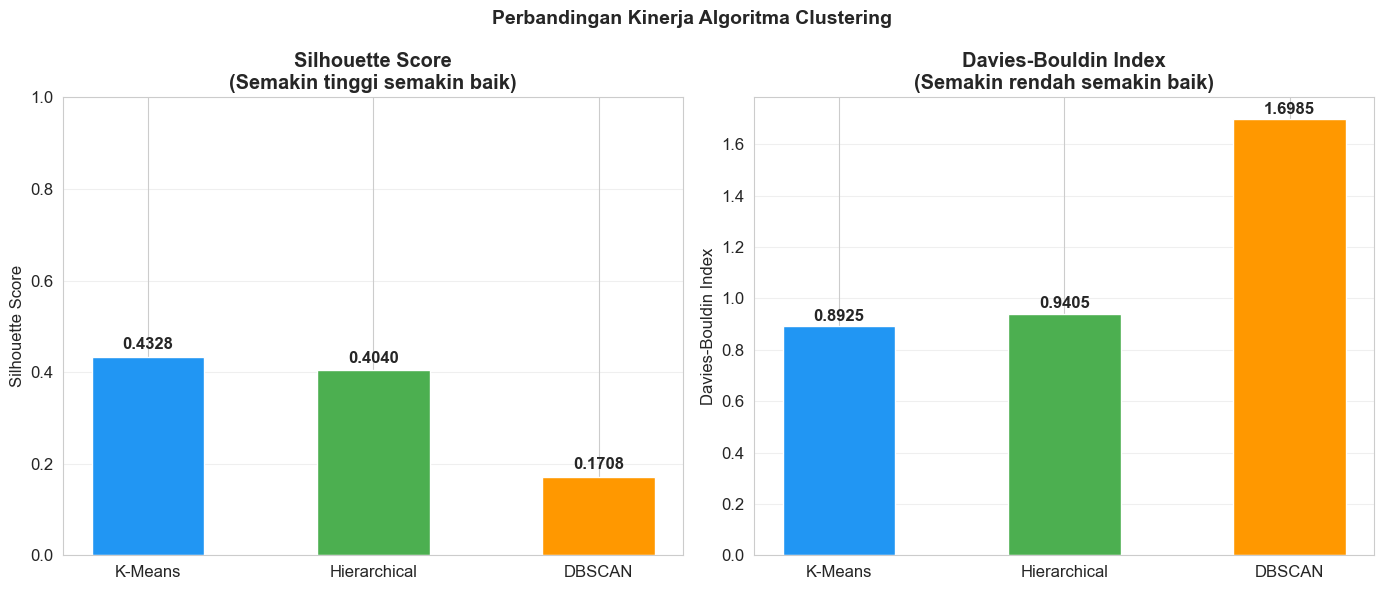

✅ Visualisasi perbandingan metrik berhasil ditampilkan


In [83]:
# ============================================================
# BAGIAN 9: PERBANDINGAN HASIL EVALUASI KETIGA METODE
# ============================================================
# Buat tabel perbandingan
tabel_evaluasi = pd.DataFrame({
    'Metode'              : ['K-Means', 'Hierarchical Clustering', 'DBSCAN'],
    'Jumlah Cluster'      : [k_optimal, k_hierarchical, n_cluster_dbscan],
    'Silhouette Score'    : [round(sil_kmeans, 4), round(sil_hc, 4), round(sil_dbscan, 4)],
    'Davies-Bouldin Index': [round(dbi_kmeans, 4), round(dbi_hc, 4), round(dbi_dbscan, 4)]
})

print("\n📋 Tabel Perbandingan Metrik Evaluasi:")
print(tabel_evaluasi.to_string(index=False))

# Visualisasi perbandingan metrik
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Perbandingan Kinerja Algoritma Clustering', fontsize=14, fontweight='bold')

warna   = ['#2196F3', '#4CAF50', '#FF9800']
metode  = ['K-Means', 'Hierarchical', 'DBSCAN']

# Silhouette Score (semakin tinggi semakin baik)
bars1 = axes[0].bar(metode,
                    [sil_kmeans, sil_hc, sil_dbscan],
                    color=warna, edgecolor='white', width=0.5)
axes[0].set_title('Silhouette Score\n(Semakin tinggi semakin baik)', fontweight='bold')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, [sil_kmeans, sil_hc, sil_dbscan]):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Davies-Bouldin Index (semakin rendah semakin baik)
dbi_vals = [dbi_kmeans, dbi_hc, min(dbi_dbscan, 5)]  # cap DBSCAN jika inf
bars2 = axes[1].bar(metode, dbi_vals, color=warna, edgecolor='white', width=0.5)
axes[1].set_title('Davies-Bouldin Index\n(Semakin rendah semakin baik)', fontweight='bold')
axes[1].set_ylabel('Davies-Bouldin Index')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, [dbi_kmeans, dbi_hc, dbi_dbscan]):
    label = f'{val:.4f}' if val != float('inf') else 'N/A'
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 label, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('perbandingan_evaluasi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi perbandingan metrik berhasil ditampilkan")


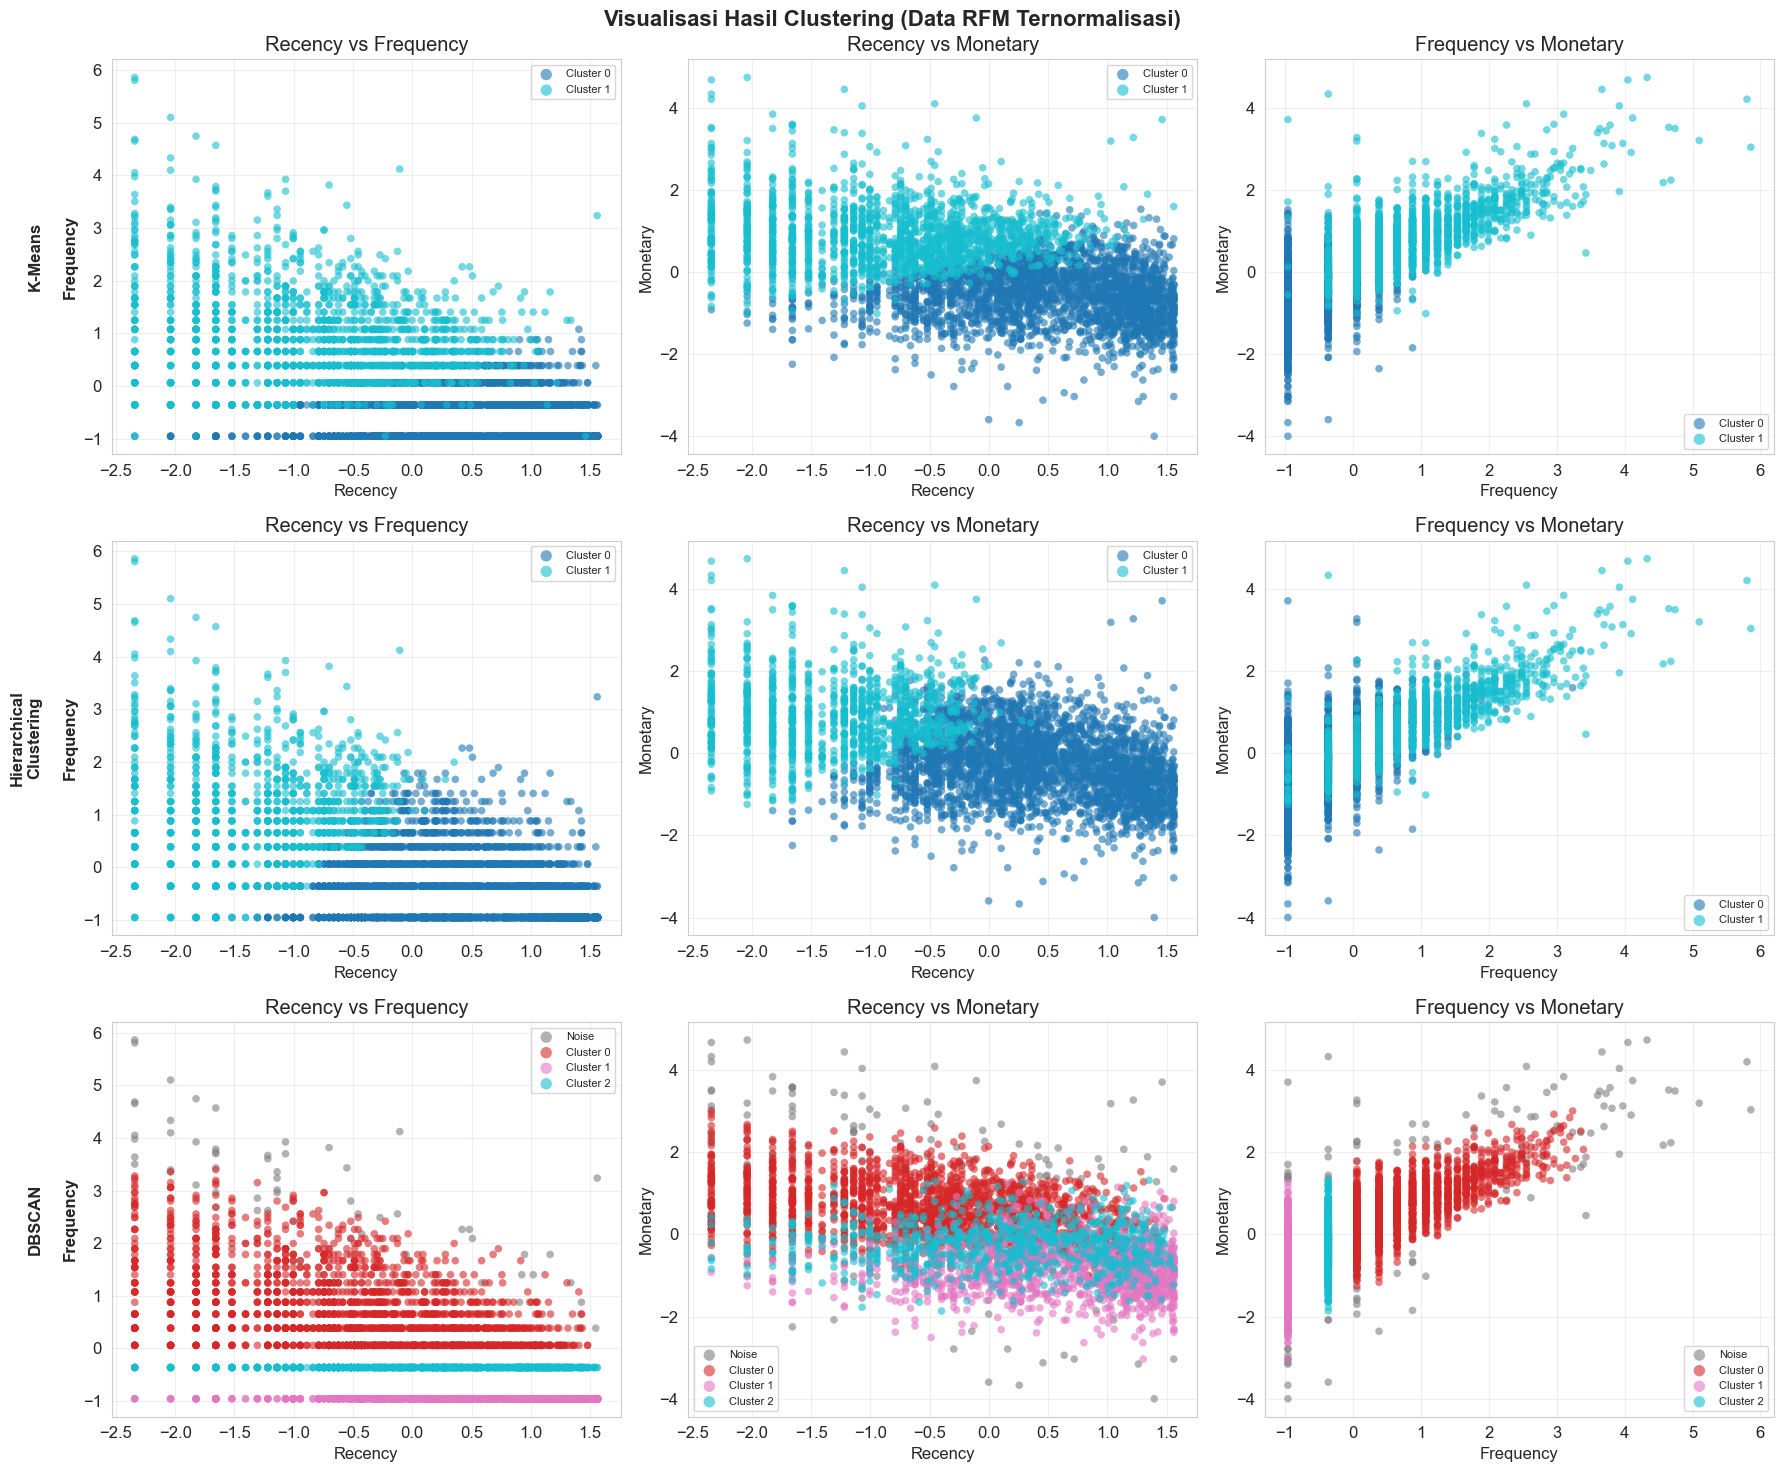

✅ Visualisasi scatter plot hasil clustering berhasil ditampilkan


In [84]:
# ============================================================
# BAGIAN 10: VISUALISASI HASIL CLUSTERING
# ============================================================

def plot_clustering(rfm_df, rfm_scaled, kolom_cluster, judul, ax_list):
    cluster_labels = rfm_df[kolom_cluster].values
    unique_labels  = sorted(set(cluster_labels))
    n_unique       = len(unique_labels)
    # Gunakan tab10 atau viridis yang punya lebih banyak warna
    # PERBAIKAN DI SINI: Memanggil colormap sebagai fungsi
    cmap = plt.colormaps['tab10']
    warna_map = {c: cmap(i / max(1, n_unique - 1)) for i, c in enumerate(unique_labels)}
    if -1 in warna_map:
        warna_map[-1] = [0.5, 0.5, 0.5, 1]

    pasangan = [('Recency', 'Frequency'), ('Recency', 'Monetary'), ('Frequency', 'Monetary')]
    kolom    = ['Recency', 'Frequency', 'Monetary']

    for ax, (x_col, y_col) in zip(ax_list, pasangan):   
        idx_x = kolom.index(x_col)
        idx_y = kolom.index(y_col)
        for cl in unique_labels:
            mask  = cluster_labels == cl
            label = f'Cluster {cl}' if cl != -1 else 'Noise'
            ax.scatter(rfm_scaled[mask, idx_x], rfm_scaled[mask, idx_y],
                       c=[warna_map[cl]], label=label, alpha=0.6, s=30, edgecolors='none')
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.set_title(f'{x_col} vs {y_col}')
        ax.legend(fontsize=8, markerscale=1.5)
        ax.grid(True, alpha=0.3)

# Plot hasil ketiga metode
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Visualisasi Hasil Clustering (Data RFM Ternormalisasi)',
             fontsize=16, fontweight='bold')

plot_clustering(rfm, rfm_scaled, 'Cluster_KMeans',       'K-Means',               list(axes[0]))
plot_clustering(rfm, rfm_scaled, 'Cluster_Hierarchical', 'Hierarchical Clustering', list(axes[1]))
plot_clustering(rfm, rfm_scaled, 'Cluster_DBSCAN',       'DBSCAN',                list(axes[2]))

for i, nama in enumerate(['K-Means', 'Hierarchical\nClustering', 'DBSCAN']):
    axes[i][0].set_ylabel(f'{nama}\n\n{axes[i][0].get_ylabel()}', fontweight='bold')

plt.tight_layout()
plt.savefig('visualisasi_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi scatter plot hasil clustering berhasil ditampilkan")


ANALISIS KARAKTERISTIK CLUSTER

📋 Profil rata-rata RFM per cluster (K-Means):
                Jumlah_Pelanggan  Recency_Rata2  Frequency_Rata2  Monetary_Rata2
Cluster_KMeans                                                                  
0                           2672         134.09             1.67          495.59
1                           1666          25.89             8.44         4539.60

📝 Interpretasi Otomatis Cluster:
------------------------------------------------------------

Cluster 0 (2672 pelanggan):
  1. TIDAK AKTIF (lama tidak bertransaksi)
  2. JARANG BERTRANSAKSI
  3. BERNILAI RENDAH (belanja kecil)

Cluster 1 (1666 pelanggan):
  1. AKTIF (transaksi baru-baru ini)
  2. LOYAL (sering bertransaksi)
  3. BERNILAI TINGGI (belanja besar)


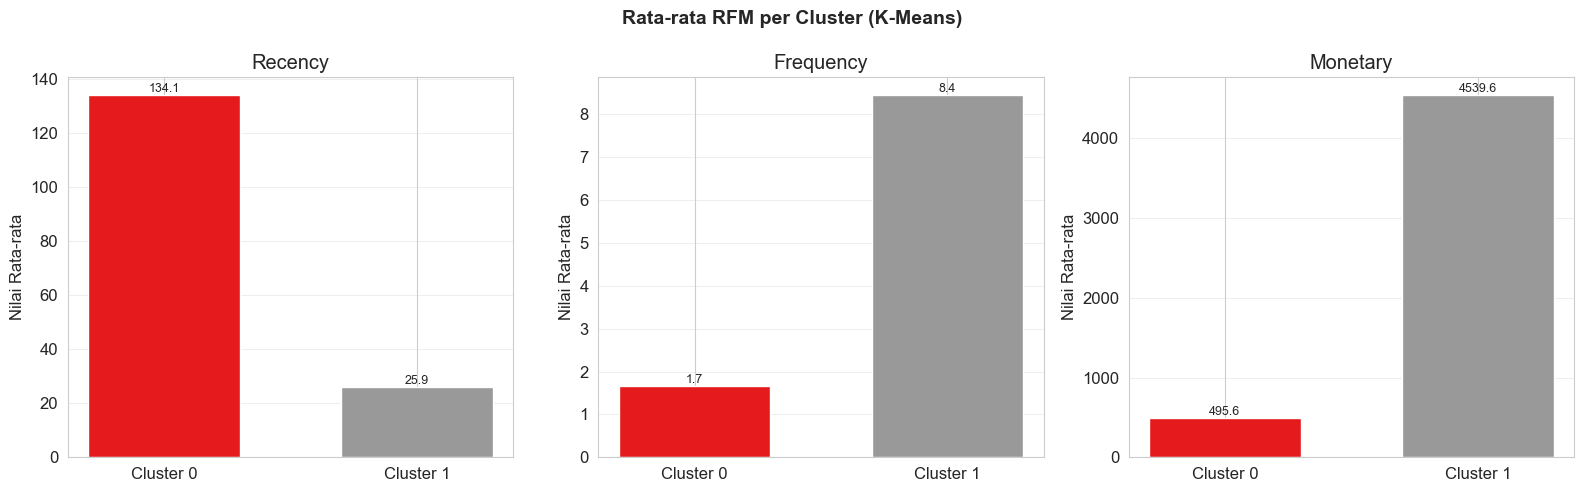


✅ Analisis karakteristik cluster selesai


In [85]:
# ============================================================
# BAGIAN 11: ANALISIS KARAKTERISTIK CLUSTER (K-MEANS)
# ============================================================

print("\n" + "="*60)
print("ANALISIS KARAKTERISTIK CLUSTER")
print("="*60)

# Tambahkan nilai RFM asli ke hasil clustering K-Means
rfm_analisis = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster_KMeans']].copy()

# Hitung rata-rata RFM per cluster
profil_cluster = rfm_analisis.groupby('Cluster_KMeans').agg(
    Jumlah_Pelanggan = ('CustomerID', 'count'),
    Recency_Rata2    = ('Recency',    'mean'),
    Frequency_Rata2  = ('Frequency',  'mean'),
    Monetary_Rata2   = ('Monetary',   'mean')
).round(2)

print("\n📋 Profil rata-rata RFM per cluster (K-Means):")
print(profil_cluster.to_string())

# Interpretasi otomatis tiap cluster
print("\n📝 Interpretasi Otomatis Cluster:")
print("-" * 60)

r_median = rfm['Recency'].median()
f_median = rfm['Frequency'].median()
m_median = rfm['Monetary'].median()

for cluster_id, row in profil_cluster.iterrows():
    interpretasi = []

    # Interpretasi Recency (semakin kecil = semakin aktif)
    if row['Recency_Rata2'] < r_median:
        interpretasi.append("AKTIF (transaksi baru-baru ini)")
    else:
        interpretasi.append("TIDAK AKTIF (lama tidak bertransaksi)")

    # Interpretasi Frequency
    if row['Frequency_Rata2'] > f_median:
        interpretasi.append("LOYAL (sering bertransaksi)")
    else:
        interpretasi.append("JARANG BERTRANSAKSI")

    # Interpretasi Monetary
    if row['Monetary_Rata2'] > m_median:
        interpretasi.append("BERNILAI TINGGI (belanja besar)")
    else:
        interpretasi.append("BERNILAI RENDAH (belanja kecil)")

    print(f"\nCluster {cluster_id} ({int(row['Jumlah_Pelanggan'])} pelanggan):")
    for i, interp in enumerate(interpretasi, 1):
        print(f"  {i}. {interp}")

# Visualisasi profil cluster (radar/bar chart)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Rata-rata RFM per Cluster (K-Means)', fontsize=14, fontweight='bold')

warna_cluster = plt.cm.Set1(np.linspace(0, 1, k_optimal))

for i, (col, ax) in enumerate(zip(['Recency_Rata2', 'Frequency_Rata2', 'Monetary_Rata2'], axes)):
    bars = ax.bar(
        [f'Cluster {c}' for c in profil_cluster.index],
        profil_cluster[col],
        color=warna_cluster[:len(profil_cluster)],
        edgecolor='white', width=0.6
    )
    ax.set_title(col.replace('_Rata2', ''))
    ax.set_ylabel('Nilai Rata-rata')
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, profil_cluster[col]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('profil_cluster_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Analisis karakteristik cluster selesai")



📊 Membuat Visualisasi Snake Plot...


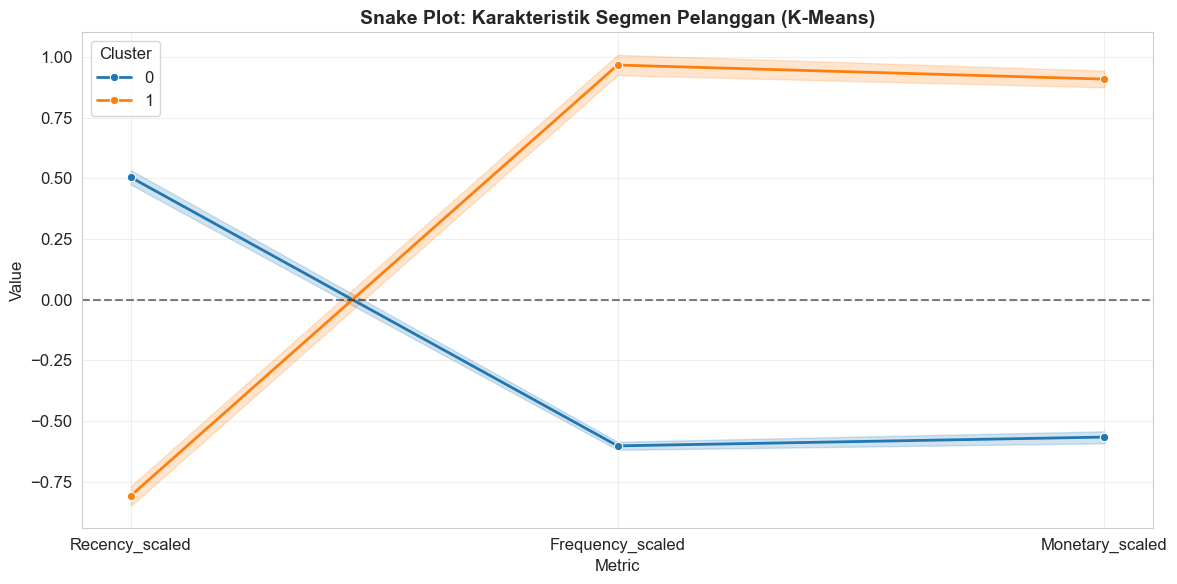

✅ Snake Plot berhasil divisualisasikan


In [86]:
# --- TAMBAHAN: VISUALISASI SNAKE PLOT ---
print("\n📊 Membuat Visualisasi Snake Plot...")

df_snake = rfm_scaled_df.copy()
df_snake = df_snake.reset_index()
df_snake['Cluster'] = rfm['Cluster_KMeans'].values
df_melt = pd.melt(df_snake.reset_index(), 
                  id_vars=['CustomerID', 'Cluster'], 
                  value_vars=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'],
                  var_name='Metric', 
                  value_name='Value')

plt.figure(figsize=(12, 6))
sns.lineplot(x='Metric', y='Value', hue='Cluster', data=df_melt, palette='tab10', marker='o', linewidth=2)
plt.title('Snake Plot: Karakteristik Segmen Pelanggan (K-Means)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('snake_plot_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Snake Plot berhasil divisualisasikan")

In [87]:
# ============================================================
# BAGIAN 12: KESIMPULAN OTOMATIS
# ============================================================

print("\n" + "="*60)
print("KESIMPULAN OTOMATIS")
print("="*60)

# Tentukan metode terbaik berdasarkan Silhouette Score tertinggi
# dan Davies-Bouldin Index terendah
scores = {
    'K-Means'                : {'sil': sil_kmeans, 'dbi': dbi_kmeans},
    'Hierarchical Clustering': {'sil': sil_hc,     'dbi': dbi_hc},
    'DBSCAN'                 : {'sil': sil_dbscan,  'dbi': dbi_dbscan}
}

# Filter hanya metode yang valid (DBSCAN bisa menghasilkan nilai tidak valid)
scores_valid = {k: v for k, v in scores.items() if v['sil'] > 0 and v['dbi'] != float('inf')}

if scores_valid:
    metode_sil_terbaik = max(scores_valid, key=lambda x: scores_valid[x]['sil'])
    metode_dbi_terbaik = min(scores_valid, key=lambda x: scores_valid[x]['dbi'])

    print(f"\n📊 Ringkasan Hasil Evaluasi:")
    print(f"   Silhouette Score tertinggi : {metode_sil_terbaik} ({scores[metode_sil_terbaik]['sil']:.4f})")
    print(f"   Davies-Bouldin Index terendah: {metode_dbi_terbaik} ({scores[metode_dbi_terbaik]['dbi']:.4f})")

    # Tentukan metode terbaik keseluruhan
    if metode_sil_terbaik == metode_dbi_terbaik:
        metode_terbaik = metode_sil_terbaik
        alasan = "unggul di kedua metrik evaluasi"
    else:
        # Jika berbeda, pilih berdasarkan Silhouette Score
        metode_terbaik = metode_sil_terbaik
        alasan = "memiliki Silhouette Score tertinggi"

    print(f"\n🏆 KESIMPULAN:")
    print(f"   Metode clustering paling optimal adalah {metode_terbaik.upper()}")
    print(f"   karena {alasan}.")
    print(f"\n   {metode_terbaik} menghasilkan:")
    print(f"   - Silhouette Score    : {scores[metode_terbaik]['sil']:.4f}")
    print(f"   - Davies-Bouldin Index: {scores[metode_terbaik]['dbi']:.4f}")
    print(f"\n   Hal ini menunjukkan bahwa {metode_terbaik} menghasilkan cluster")
    print(f"   yang paling kompak dan terpisah dengan baik pada dataset")
    print(f"   transaksi e-commerce yang dianalisis.")
else:
    print("\n⚠️  Tidak semua metode menghasilkan metrik yang valid.")
    print("   Periksa kembali parameter DBSCAN dan jumlah cluster.")

# Tampilkan tabel evaluasi final
print("\n📋 Tabel Evaluasi Final:")
print(tabel_evaluasi.to_string(index=False))

print("\n" + "="*60)
print("✅ SELURUH PROSES PENELITIAN SELESAI")
print("="*60)
print("\nFile yang dihasilkan:")
print("  1. distribusi_rfm.png")
print("  2. heatmap_korelasi_rfm.png")
print("  3. pairplot_rfm.png")
print("  4. kmeans_elbow_silhouette.png")
print("  5. hierarchical_dendrogram.png")
print("  6. dbscan_kdistance.png")
print("  7. perbandingan_evaluasi.png")
print("  8. visualisasi_clustering.png")
print("  9. profil_cluster_kmeans.png")
print("  10. snake_plot_kmeans.png")
print("  11. rfm_hasil_clustering.csv")


KESIMPULAN OTOMATIS

📊 Ringkasan Hasil Evaluasi:
   Silhouette Score tertinggi : K-Means (0.4328)
   Davies-Bouldin Index terendah: K-Means (0.8925)

🏆 KESIMPULAN:
   Metode clustering paling optimal adalah K-MEANS
   karena unggul di kedua metrik evaluasi.

   K-Means menghasilkan:
   - Silhouette Score    : 0.4328
   - Davies-Bouldin Index: 0.8925

   Hal ini menunjukkan bahwa K-Means menghasilkan cluster
   yang paling kompak dan terpisah dengan baik pada dataset
   transaksi e-commerce yang dianalisis.

📋 Tabel Evaluasi Final:
                 Metode  Jumlah Cluster  Silhouette Score  Davies-Bouldin Index
                K-Means               2            0.4328                0.8925
Hierarchical Clustering               2            0.4040                0.9405
                 DBSCAN               3            0.1708                1.6985

✅ SELURUH PROSES PENELITIAN SELESAI

File yang dihasilkan:
  1. distribusi_rfm.png
  2. heatmap_korelasi_rfm.png
  3. pairplot_rfm.png
  4. k

In [88]:
# Ekspor data hasil clustering untuk Dashboard
rfm_final = rfm_scaled_df.copy()
rfm_final['Cluster'] = rfm['Cluster_KMeans'].values
# Kembalikan nilai asli untuk ditampilkan di dashboard
rfm_final['Recency_Asli'] = rfm['Recency'].values
rfm_final['Frequency_Asli'] = rfm['Frequency'].values
rfm_final['Monetary_Asli'] = rfm['Monetary'].values

rfm_final.to_csv('rfm_hasil_clustering.csv', index=True)
print("✅ File rfm_hasil_clustering.csv berhasil disimpan untuk Dashboard!")

✅ File rfm_hasil_clustering.csv berhasil disimpan untuk Dashboard!
